# MEIA Challenge 3 — EDA

Análise exploratória dos datasets de logs Sysmon.

In [9]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from preprocessor import parse_csv, make_windows
from detectors import IForestDetector, tag_techniques

# Shared path used by result-loading sections
results_path = Path('../results')


## 1. Carregar dados

In [10]:
df = parse_csv(Path('../data/samples/LMD-2023 [1.75M Elements - Normal]checked.csv'), dataset='lmd')
print(f'Events: {len(df)}')
print(f'Time range: {df.timestamp.min()} → {df.timestamp.max()}')
df.head()

Events: 687350
Time range: 2026-03-24 00:00:06+00:00 → 2026-03-24 23:59:54+00:00


,unnamed: 0,label,name,guid,event_id,version,level,task,opcode,keywords,...,sourceprocessguid,targetprocessguid,newthreadid,startaddress,startmodule,startfunction,previouscreationutctime,hash,contents,id
0,25965,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
1,25964,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
2,7132,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,3,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
3,809689,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
4,809687,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0


## 2. Distribuição de EventIDs

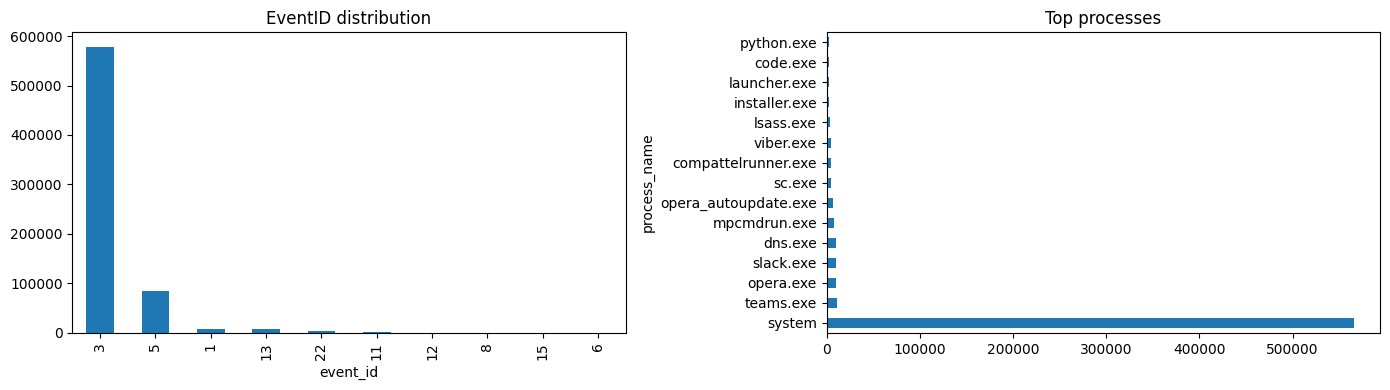

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['event_id'].value_counts().plot(kind='bar', ax=axes[0], title='EventID distribution')
df['process_name'].value_counts().head(15).plot(kind='barh', ax=axes[1], title='Top processes')

plt.tight_layout()
plt.show()

## 3. Windowing e features

In [12]:
windows = list(make_windows(df, window_size_seconds=60))
print(f'Windows: {len(windows)}')

wdf = pd.DataFrame([w.to_dict() for w in windows])
wdf[['event_count', 'suspicious_process_count', 'network_connection_count',
     'powershell_count', 'has_mimikatz', 'has_psexec']].describe()

Windows: 1424


,event_count,suspicious_process_count,network_connection_count,powershell_count
count,1424.000000,1424.000000,1424.000000,1424.000000
mean,84.112360,1.603230,53.537921,0.084972
std,84.234789,14.810322,80.459860,0.697712
min,1.000000,0.000000,0.000000,0.000000
25%,13.000000,0.000000,0.000000,0.000000
50%,35.500000,0.000000,8.000000,0.000000
75%,200.000000,0.000000,97.250000,0.000000
max,200.000000,200.000000,200.000000,12.000000


## 4. IsolationForest scoring

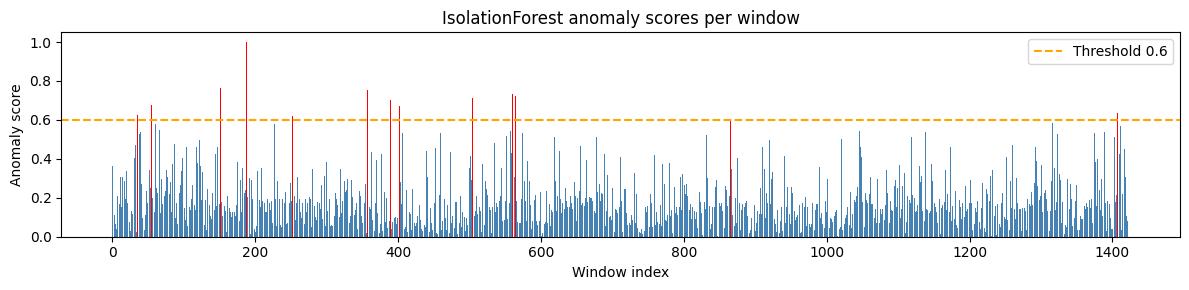

Windows above threshold: 24/1424


In [13]:
import numpy as np

X = np.array([w.to_feature_vector() for w in windows])
iforest = IForestDetector()
iforest.fit(X)
scores = iforest.score(X)

wdf['if_score'] = scores

plt.figure(figsize=(12, 3))
plt.bar(range(len(scores)), scores, color=['red' if s > 0.6 else 'steelblue' for s in scores])
plt.axhline(0.6, color='orange', linestyle='--', label='Threshold 0.6')
plt.xlabel('Window index')
plt.ylabel('Anomaly score')
plt.title('IsolationForest anomaly scores per window')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Windows above threshold: {(scores > 0.6).sum()}/{len(scores)}')

## 5. ATT&CK rule tagging

In [14]:
for i, w in enumerate(windows):
    hits = tag_techniques(w.to_dict())
    if hits:
        print(f'Window {i} (score={scores[i]:.2f}):')
        for h in hits:
            print(f'  {h["technique"]} {h["name"]} conf={h["confidence"]}')

Window 0 (score=0.36):
  T1547.001 Registry Run Keys conf=0.5
Window 2 (score=0.16):
  T1547.001 Registry Run Keys conf=0.5
Window 11 (score=0.31):
  T1547.001 Registry Run Keys conf=0.5
Window 12 (score=0.25):
  T1547.001 Registry Run Keys conf=0.5
Window 13 (score=0.15):
  T1547.001 Registry Run Keys conf=0.5
Window 14 (score=0.31):
  T1547.001 Registry Run Keys conf=0.5
Window 17 (score=0.28):
  T1021.002 SMB/Windows Admin Shares conf=0.6
Window 28 (score=0.12):
  T1021.002 SMB/Windows Admin Shares conf=0.6
Window 33 (score=0.29):
  T1021.002 SMB/Windows Admin Shares conf=0.6
Window 35 (score=0.63):
  T1021.002 SMB/Windows Admin Shares conf=0.6
  T1570 Lateral Tool Transfer (PsExec) conf=0.85
Window 37 (score=0.34):
  T1021.002 SMB/Windows Admin Shares conf=0.6
Window 39 (score=0.54):
  T1547.001 Registry Run Keys conf=0.5
  T1003 Credential Dumping conf=0.95
Window 40 (score=0.24):
  T1021.002 SMB/Windows Admin Shares conf=0.6
Window 41 (score=0.27):
  T1021.002 SMB/Windows Admin S

## 6. Análise dos resultados do judge (se existirem)

In [15]:
judge_files = list(results_path.rglob('judge_results.json'))

if judge_files:
    with open(sorted(judge_files)[-1]) as f:
        judge_data = json.load(f)

    if not judge_data:
        print('judge_results.json encontrado mas está vazio (0 janelas julgadas).')
        print('Verifica se o threshold está baixo o suficiente para escalarem janelas ao judge.')
    else:
        jdf = pd.DataFrame(judge_data)
        print(f'Judge results: {len(jdf)}')

        # Verdict distribution
        if 'verdict' in jdf.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            jdf['verdict'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'],
                                               title='Verdict distribution')
            axes[0].set_xlabel('Verdict')
            axes[0].set_ylabel('Count')

            if 'anomaly_score' in jdf.columns:
                axes[1].hist(jdf['anomaly_score'], bins=range(12), color='steelblue', edgecolor='white')
                axes[1].axvline(7, color='red', linestyle='--', label='High-risk (≥7)')
                axes[1].set_xlabel('Anomaly score')
                axes[1].set_ylabel('Count')
                axes[1].set_title('Anomaly score distribution')
                axes[1].legend()

            plt.tight_layout()
            plt.show()

        cols = [c for c in ['window_start', 'anomaly_score', 'verdict', 'detector_score',
                             'slm_pre_score', 'fp_risk'] if c in jdf.columns]
        print(jdf[cols].to_string())
else:
    print('Nenhum ficheiro de judge results encontrado. Corre o pipeline primeiro.')


Nenhum ficheiro de judge results encontrado. Corre o pipeline primeiro.


## 7. SLM Analyst pre-diagnoses (se existirem)

In [16]:
slm_files = list(results_path.rglob('slm_analyses.json'))

if slm_files:
    with open(sorted(slm_files)[-1]) as f:
        slm_data = json.load(f)

    if not slm_data:
        print('slm_analyses.json encontrado mas está vazio.')
    else:
        sdf = pd.DataFrame(slm_data)
        print(f'SLM analyses: {len(sdf)}')

        # Pre-filter stats (trivially benign = pre_score 0 and summary contains "pre-filter")
        if 'summary' in sdf.columns:
            prefiltered = sdf['summary'].str.contains('pre-filter', na=False).sum()
            ollama_calls = len(sdf) - prefiltered
            print(f'  Trivially-benign pre-filter: {prefiltered} | Real Ollama calls: {ollama_calls}')

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # pre_score distribution
        if 'pre_score' in sdf.columns:
            sdf['pre_score'].value_counts().sort_index().plot(
                kind='bar', ax=axes[0], color='steelblue', title='SLM pre_score distribution')
            axes[0].set_xlabel('pre_score')
            axes[0].set_ylabel('Count')

        # risk_level breakdown
        if 'risk_level' in sdf.columns:
            color_map = {'low': 'green', 'medium': 'gold', 'high': 'orange', 'critical': 'red'}
            rl = sdf['risk_level'].value_counts()
            colors = [color_map.get(l, 'steelblue') for l in rl.index]
            rl.plot(kind='bar', ax=axes[1], color=colors, title='Risk level breakdown')
            axes[1].set_xlabel('Risk level')
            axes[1].set_ylabel('Count')

        # needs_deep_analysis
        if 'needs_deep_analysis' in sdf.columns:
            sdf['needs_deep_analysis'].value_counts().plot(
                kind='bar', ax=axes[2], color=['green', 'orange'],
                title='needs_deep_analysis')
            axes[2].set_xlabel('Needs deep analysis')
            axes[2].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

        cols = [c for c in ['window_start', 'pre_score', 'risk_level',
                             'needs_deep_analysis', 'summary'] if c in sdf.columns]
        print(sdf[cols].to_string())
else:
    print('Nenhum ficheiro de SLM analyses encontrado. Corre o pipeline primeiro.')


Nenhum ficheiro de SLM analyses encontrado. Corre o pipeline primeiro.


## 8. Janelas scored — detector scores + ATT&CK hits (windows_scored.json)

Scored windows: 1424


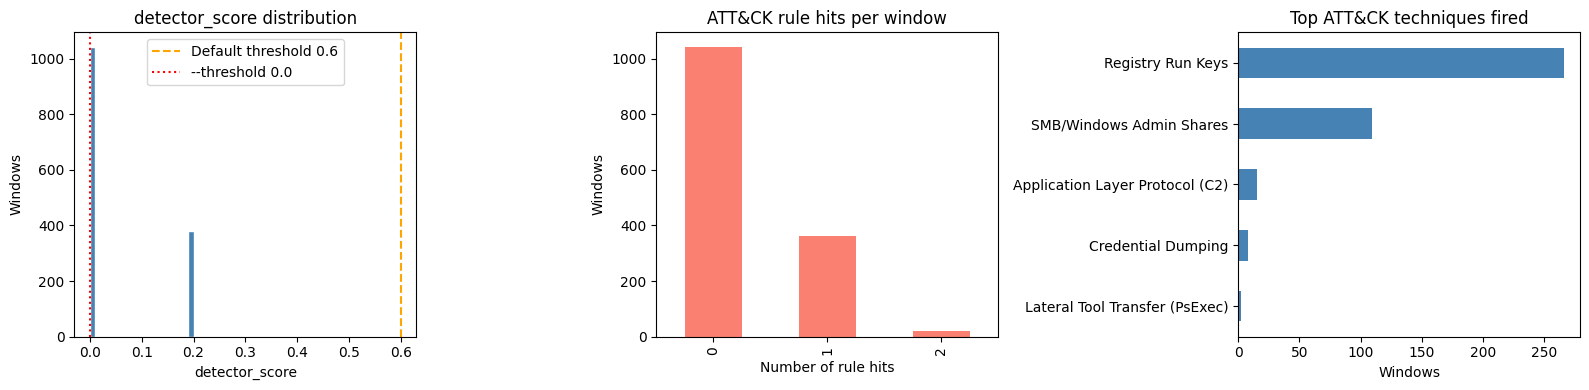

             window_start  event_count  if_score  gru_score  detector_score  attck_hit_count
2026-03-24T23:44:00+00:00           45       0.0        0.0             0.2                1
2026-03-24T23:45:00+00:00          200       0.0        0.0             0.2                1
2026-03-24T23:48:00+00:00          200       0.0        0.0             0.2                1
2026-03-24T23:49:00+00:00           24       0.0        0.0             0.2                1
2026-03-24T23:50:00+00:00           42       0.0        0.0             0.2                1
2026-03-24T23:51:00+00:00           25       0.0        0.0             0.2                1
2026-03-24T23:52:00+00:00           48       0.0        0.0             0.2                2
2026-03-24T23:53:00+00:00          200       0.0        0.0             0.2                1
2026-03-24T23:54:00+00:00           75       0.0        0.0             0.2                1
2026-03-24T23:55:00+00:00            5       0.0        0.0           

In [17]:
ws_files = list(results_path.rglob('windows_scored.json'))

if ws_files:
    with open(sorted(ws_files)[-1]) as f:
        ws_data = json.load(f)

    wsdf = pd.DataFrame(ws_data)
    print(f'Scored windows: {len(wsdf)}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # detector_score distribution
    if 'detector_score' in wsdf.columns:
        axes[0].hist(wsdf['detector_score'], bins=20, color='steelblue', edgecolor='white')
        axes[0].axvline(0.6, color='orange', linestyle='--', label='Default threshold 0.6')
        axes[0].axvline(0.0, color='red', linestyle=':', label='--threshold 0.0')
        axes[0].set_xlabel('detector_score')
        axes[0].set_ylabel('Windows')
        axes[0].set_title('detector_score distribution')
        axes[0].legend()

    # ATT&CK hits per window
    if 'attck_hits' in wsdf.columns:
        wsdf['attck_hit_count'] = wsdf['attck_hits'].apply(len)
        wsdf['attck_hit_count'].value_counts().sort_index().plot(
            kind='bar', ax=axes[1], color='salmon', title='ATT&CK rule hits per window')
        axes[1].set_xlabel('Number of rule hits')
        axes[1].set_ylabel('Windows')

    # Top ATT&CK techniques
    if 'attck_hits' in wsdf.columns:
        from collections import Counter
        tech_counter = Counter(
            h['name']
            for hits in wsdf['attck_hits']
            for h in hits
        )
        if tech_counter:
            tc_df = pd.Series(tech_counter).sort_values(ascending=True)
            tc_df.plot(kind='barh', ax=axes[2], color='steelblue',
                       title='Top ATT&CK techniques fired')
            axes[2].set_xlabel('Windows')

    plt.tight_layout()
    plt.show()

    score_cols = [c for c in ['window_start', 'event_count', 'if_score', 'gru_score',
                               'detector_score', 'attck_hit_count'] if c in wsdf.columns]
    print(wsdf[score_cols].sort_values('detector_score', ascending=False).head(20).to_string(index=False))
else:
    print('windows_scored.json não encontrado. Corre o pipeline primeiro.')


## 9. Correlação de scores — detector → SLM pre_score → Judge anomaly_score

In [18]:
# Merge windows_scored + slm_analyses + judge_results on window_start for a unified view.
# Only renders when all three output files exist (i.e. a full pipeline run has been done).

ws_files = list(results_path.rglob('windows_scored.json'))
slm_files = list(results_path.rglob('slm_analyses.json'))
judge_files = list(results_path.rglob('judge_results.json'))

if ws_files and slm_files and judge_files:
    run_dir = sorted(ws_files)[-1].parent  # use the most recent run's directory

    with open(run_dir / 'windows_scored.json') as f:
        _ws = pd.DataFrame(json.load(f))[['window_start', 'detector_score']]
    with open(run_dir / 'slm_analyses.json') as f:
        _slm = pd.DataFrame(json.load(f))[['window_start', 'pre_score', 'risk_level']]
    with open(run_dir / 'judge_results.json') as f:
        _j_raw = json.load(f)

    if _j_raw:
        _j = pd.DataFrame(_j_raw)[['window_start', 'anomaly_score', 'verdict']]
        merged = _ws.merge(_slm, on='window_start', how='left') \
                    .merge(_j, on='window_start', how='left')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # detector_score vs SLM pre_score (all SLM-analysed windows)
        slm_merged = _ws.merge(_slm, on='window_start', how='inner')
        sc = axes[0].scatter(slm_merged['detector_score'], slm_merged['pre_score'],
                             alpha=0.4, s=20, c=slm_merged['pre_score'],
                             cmap='RdYlGn_r')
        plt.colorbar(sc, ax=axes[0], label='pre_score')
        axes[0].set_xlabel('detector_score')
        axes[0].set_ylabel('SLM pre_score')
        axes[0].set_title('detector_score vs SLM pre_score')

        # SLM pre_score vs Judge anomaly_score (only judged windows)
        judge_merged = _slm.merge(_j, on='window_start', how='inner')
        verdict_colors = {'normal': 'green', 'suspicious': 'orange', 'malicious': 'red'}
        for verdict, group in judge_merged.groupby('verdict'):
            axes[1].scatter(group['pre_score'], group['anomaly_score'],
                            label=verdict, color=verdict_colors.get(verdict, 'grey'),
                            alpha=0.7, s=60)
        axes[1].set_xlabel('SLM pre_score')
        axes[1].set_ylabel('Judge anomaly_score')
        axes[1].set_title('SLM pre_score vs Judge anomaly_score')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f'Correlation (detector_score, pre_score): '
              f'{slm_merged["detector_score"].corr(slm_merged["pre_score"]):.3f}')
        print(f'Correlation (pre_score, anomaly_score):  '
              f'{judge_merged["pre_score"].corr(judge_merged["anomaly_score"]):.3f}')
    else:
        print('judge_results.json está vazio — sem janelas julgadas para correlacionar.')
else:
    print('Precisa de windows_scored.json, slm_analyses.json e judge_results.json no mesmo run. '
          'Corre o pipeline completo primeiro.')


Precisa de windows_scored.json, slm_analyses.json e judge_results.json no mesmo run. Corre o pipeline completo primeiro.
